In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Mean-Variance Portfolio Optimization and Efficient Frontier Analysis
---

## 1. Introduction

Portfolio optimization is a fundamental problem in quantative finance.
The goal is to allocate capital across multiple assets in a way that optimizes the tradeoff between expected return and risk.

In this project, we study a portfolio composed of 8 US stocks.
Although the assets are denominated in USD, performance will be evaluated from the perspective of a EUR-based investor.

We allow short-selling and include a risk-free asset in order to construct:

- The Global Minimum Variance Portfolio
- The Efficient Frontier
- The Maximum Sharpe (Tangency) Portfolio

The results will be compared against a simple equal-weight benchmark portfolio.


## 2. Research question

This project investigates how mean-variance portfolio optimization with short-selling performs relative to an equal-weight portfolio for a set of 8 US stocks, when evaluated of the perspective of a EUR-based investor including risk-free asset.

## 3. Assets

The portfolio consists of 8 large-cap US stocks across different sectors:

- Technology: AAPL, MSFT
- Healthcare: JNJ, PFE
- Consumer: KO, WMT
- Energy: XOM
- Finance: JPM

This diversified sector exposure allows meaningful covariance structure analysis and realistic portfolio construction.

## 4. Data description

We use 5 years of historical daily price data for the selected 8 US stocks

- Frequency: Daily
- Data type: Adjusted Close prices
- Period: Last 5 years
- Currency of assets: USD
- Base evaluation currency: EUR

Daily returns will be computed from adjusted closing prices.
The analysis will use log-returns for mathematical consistency.


## 5. Data download and currency conversion

We download 5 years of daily adjusted closing prices for the selected US stocks.

Since the assets are denominated in USD but evaluated from a EUR-based investor perspective, we convert prices into EUR using the EUR/USD exchange rate.


In [2]:
# Defining tickers
tickers = ["AAPL", "MSFT", "JNJ", "PFE", "KO", "WMT", "XOM", "JPM"]
fx_ticker = "EURUSD=X"

# Defining 5 years date range
end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(years=5)

# Downloading stock prices in USD and extracting close prices
stocks_raw = yf.download(tickers, start=start_date, end=end_date, progress=False)
prices_usd = stocks_raw['Close'].dropna(how='all')

# Downloading EUR/USD rate
fx_raw = yf.download(fx_ticker, start=start_date, end=end_date, progress=False)
eurusd = fx_raw[("Close", fx_ticker)].dropna()

# Converting USD prices to EUR
eur_per_usd = 1 / eurusd
data = prices_usd.join(eur_per_usd.rename("EUR_per_USD"), how="inner")
prices_eur = data[tickers].mul(data["EUR_per_USD"], axis=0).dropna()

prices_eur.head()


,AAPL,MSFT,JNJ,PFE,KO,WMT,XOM,JPM
Date,,,,,,,,
2021-03-11,99.604161,190.792603,115.875975,22.673359,36.704923,34.504161,42.447249,113.950737
2021-03-12,98.349530,188.732155,115.628857,22.709277,36.448692,34.848394,42.689284,114.724451
2021-03-15,101.059166,188.547434,116.573964,23.084274,37.045178,34.773827,41.726520,114.496177
2021-03-16,102.554878,191.263838,117.502545,23.405530,37.258640,34.834019,40.925083,113.355353
2021-03-17,102.099902,191.111382,117.303004,23.426799,37.348751,34.614190,41.188418,114.754177


## 6. Return calculation

Portfolio operates on asset returns rather than prices.

We compute daily-log returns defined as:
$$ r_t =  \ln\left(\frac{P_t}{P_{t - 1}}\right) $$

where:

- $ P_t \text{ is the asset price at time } t $
- $ P_{t-1} \text{ is at previous time step}$

Log returns are preferred because:

- They are time additive
- They simplify mathematical derivations
- They are commonly used in quantative finance





In [3]:
log_returns = np.log(prices_eur / prices_eur.shift(1))
log_returns = log_returns.dropna()
log_returns.head()

,AAPL,MSFT,JNJ,PFE,KO,WMT,XOM,JPM
Date,,,,,,,,
2021-03-12,-0.012676,-0.010858,-0.002135,0.001583,-0.007005,0.009927,0.005686,0.006767
2021-03-15,0.027178,-0.000979,0.008140,0.016378,0.016233,-0.002142,-0.022811,-0.001992
2021-03-16,0.014692,0.014304,0.007934,0.013821,0.005746,0.001729,-0.019394,-0.010014
2021-03-17,-0.004446,-0.000797,-0.001700,0.000908,0.002416,-0.006331,0.006414,0.012265
2021-03-18,-0.041288,-0.033819,-0.008663,-0.007354,-0.019957,-0.019938,-0.050872,0.009577


## 7. Estimation of Expected Returns and Covariance Matrix

Mean–variance portfolio optimization requires two main inputs:

- The expected return vector $\mu$
- The covariance matrix of asset returns $\Sigma$

These quantities are unknown in practice and must be estimated from historical data.

### Expected Return Vector

Let $r_t \in \mathbb{R}^n$ denote the vector of daily log-returns at time $t$, where $n$ is the number of assets.

We estimate the expected return using the sample mean:

$$\hat{\mu} = \frac{1}{T} \sum_{t=1}^{T} r_t$$

Here:
- $T$ is the number of observations
- $\hat{\mu} \in \mathbb{R}^n$
- Each element $\hat{\mu}_i$ represents the estimated expected return of asset $i$

### Covariance Matrix

Risk depends on how assets move together.
We estimate the covariance matrix as:

$$\hat{\Sigma} = \text{Cov}(r)$$

Each element of the matrix is:

$$\hat{\Sigma}_{ij} = \text{Cov}(r_i, r_j)$$

Where:
- $\hat{\Sigma} \in \mathbb{R}^{n \times n}$
- The diagonal elements $\hat{\Sigma}_{ii}$ represent variances
- The off-diagonal elements represent covariances

In [4]:
# Daily estimates
expected_daily_returns = log_returns.mean()
daily_covariance_matrix = log_returns.cov()

trading_days_per_year = 252

# Annualized expected returns
expected_annual_returns = expected_daily_returns * trading_days_per_year

# Annualized covariance matrix
annual_cov_matrix = daily_covariance_matrix * trading_days_per_year

expected_annual_returns, annual_cov_matrix.head()


(AAPL    0.163460
 MSFT    0.121610
 JNJ     0.119374
 PFE     0.006164
 KO      0.121144
 WMT     0.228930
 XOM     0.221214
 JPM     0.156836
 dtype: float64,
           AAPL      MSFT       JNJ       PFE        KO       WMT       XOM  \
 AAPL  0.082731  0.049476  0.013467  0.020065  0.018553  0.022393  0.021467   
 MSFT  0.049476  0.073997  0.007931  0.014370  0.013019  0.017612  0.010764   
 JNJ   0.013467  0.007931  0.033479  0.023461  0.017799  0.014418  0.011613   
 PFE   0.020065  0.014370  0.023461  0.069197  0.016822  0.012888  0.015357   
 KO    0.018553  0.013019  0.017799  0.016822  0.031099  0.017905  0.013453   
 
            JPM  
 AAPL  0.030546  
 MSFT  0.025253  
 JNJ   0.012666  
 PFE   0.016642  
 KO    0.013730  )

## 8. Global Minimum Variance Portfolio (GMVP)

The Global Minimum Variance Portfolio (GMVP) is the portfolio with the lowest possible variance among all fully-invested portfolios (i.e., portfolios whose weights sum to 1). It depends only on the covariance structure of asset returns and does not require specifying a target return.

Let:

- $ w \in \mathbb{R}^n$ be the vector of portfolio weights (one weight per asset)
- $ \Sigma \in \mathbb{R}^{n \times n} $ be the (annualized) covariance matrix of asset returns.

The portfolio variance is:

$$ \text{Var}(R_p) = w^T\Sigma w $$

### Optimization problem

Since we allow short-selling, weights may be negative. The GMVP is defined by:

$$ \min_{w} \quad w^{T} \Sigma w$$

subject to:

$$ 1^{T} w = 1 $$

where $1$ is a vector of ones

The constraint $ 1^{T} w = 1 $ enforces that the portfolio is fully invested (all capital allocated).

### Closed-form solution (Lagrange multipliers)
We solve the constrained optimization using a Lagrangian:

$$ \mathcal{L}(w,\lambda) = w^{T}\Sigma w - \lambda(1^{T}w - 1) $$

Taking derivatives with respect to $ w $ and setting them to zero:

$$ \nabla_w \mathcal{L} = 2\Sigma w - \lambda \mathbf{1} = 0 \quad \implies \quad \Sigma w = \frac{\lambda}{2}\mathbf{1}$$

Assuming $ \Sigma $ is invertible:

$$ w = \frac{\lambda}{2}\Sigma^{-1}\mathbf{1} $$

Apply the constraint $ 1^{T} w = 1 $:

$$
\mathbf{1}^{T} \left( \frac{\lambda}{2}\Sigma^{-1}\mathbf{1} \right) = 1
\quad \implies \quad
\frac{\lambda}{2} = \frac{1}{\mathbf{1}^{T}\Sigma^{-1}\mathbf{1}}
$$

Substitute back to obtain the GMVP weights:
$$ w_{\mathrm{GMVP}} = \frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}^{T}\Sigma^{-1}\mathbf{1}} $$

### Compute Global Minimum Variance Portfolio

In [5]:
# Number of assets
number_of_assets = len(tickers)

# Annual expected returns as Series
annual_expected_returns = expected_annual_returns.copy()

# Annual covariance as DataFrame (keep labels!)
annual_cov_df = daily_covariance_matrix * 252
annual_cov_df = annual_cov_df.loc[tickers, tickers]

# Vector of ones as Series
ones = pd.Series(1.0, index=tickers)

# Invert covariance matrix
inv_cov = pd.DataFrame(
    np.linalg.inv(annual_cov_df.values),
    index=tickers,
    columns=tickers
)

# GMVP weights:
numerator = inv_cov @ ones
denominator = float(ones.T @ inv_cov @ ones)
gmvp_weights = numerator / denominator

gmvp_weights_sorted = gmvp_weights.sort_values(ascending=False)

gmvp_weights_sorted

JNJ     0.285481
KO      0.269866
MSFT    0.147338
WMT     0.126588
XOM     0.106300
JPM     0.075755
PFE     0.044568
AAPL   -0.055895
dtype: float64

In [6]:
# Verifying Full Investment Constraint

gmvp_weights.sum() # should return approx 1.0

np.float64(1.0000000000000002)

### Expected Return and Risk of GMVP

In [7]:
# Expected annual return
gmvp_return = float(gmvp_weights.T @ annual_expected_returns)

# Portfolio variance
gmvp_variance = float(gmvp_weights.T @ annual_cov_df @ gmvp_weights)

# Portfolio volatility
gmvp_volatility = float(np.sqrt(gmvp_variance))

gmvp_return, gmvp_volatility

(0.14020308253139255, 0.14086050929108382)

### Comparing with Equal Weight Portfolio

In [8]:
# Equal-weight portfolio as Series with labels
equal_weight_weights = pd.Series(1/number_of_assets, index=tickers)

equal_weight_return = float(equal_weight_weights.T @ annual_expected_returns)
equal_weight_variance = float(equal_weight_weights.T @ annual_cov_df @ equal_weight_weights)
equal_weight_volatility = float(np.sqrt(equal_weight_variance))

comparison_table = pd.DataFrame({
    "Expected Annual Return": [gmvp_return, equal_weight_return],
    "Annual Volatility": [gmvp_volatility, equal_weight_volatility]
}, index=["Minimum Variance Portfolio", "Equal Weight Portfolio"])

comparison_table

,Expected Annual Return,Annual Volatility
Minimum Variance Portfolio,0.140203,0.140861
Equal Weight Portfolio,0.142341,0.152941


### Portfolio Weights

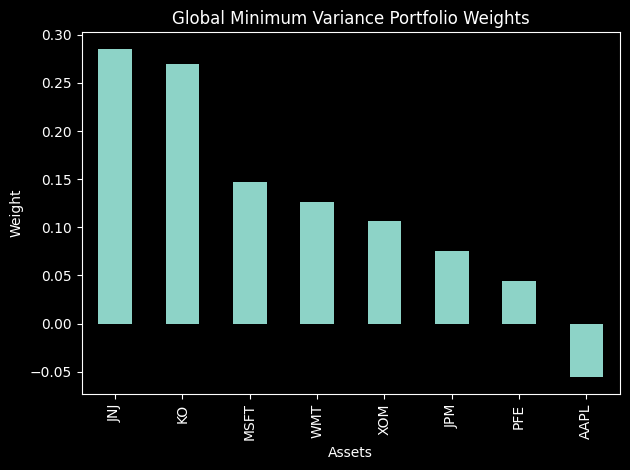

In [9]:
gmvp_weights_sorted.plot(
    kind="bar",
    title="Global Minimum Variance Portfolio Weights"
)

plt.ylabel("Weight")
plt.xlabel("Assets")
plt.tight_layout()
plt.show()

In [10]:
print("GMVP variance:", gmvp_variance)
print("EW variance:", equal_weight_variance)
print("GMVP <= EW ?", gmvp_variance <= equal_weight_variance)

GMVP variance: 0.019841683077743512
EW variance: 0.023390903493909408
GMVP <= EW ? True


## 9. Random Portfolio Simulation

To visualize the space of feasible portfolios and the risk-return tradeoff we generate a large number of random portfolios.

For each simulated portfolio we:

1. Randomly generate portfolio weights
2. Normalize weights, so that they sum to 1 (which means fully invested portfolio)
3. Compute expected annual return using the estimated mean vector
4. Compute the annual volatility using the estimated covariance matrix

Plotting all simulated portfolios in return-volatility in space produces a "cloud" of feasible portfolios.
The **lower boundry** of this cloud corresponds to portfolios with the **lowest volatility** for a given return, which motivates the construction of the **efficient frontier** in the next section.


## Long-only random portfolios

First, we simulate portfolios under the **long-only constraint**, meaning that portfolio weights must be non-negative and sum to one.

This corresponds to a realistic scenario for many investors who are not allowed to short-sell assets.

We generate random weights using a **Dirichlet distribution**, which guarantees that:

- all weights are positive
- weights sum exactly to 1

For each random portfolio we compute the expected annual return and volatility.

In [11]:
number_of_portfolios = 20000

long_only_returns = np.zeros(number_of_portfolios)
long_only_volatility = np.zeros(number_of_portfolios)

for i in range(number_of_portfolios):

    weights = np.random.dirichlet(np.ones(number_of_assets))
    weights = pd.Series(weights, index=tickers)

    portfolio_return = float(weights.T @ annual_expected_returns)
    portfolio_variance = float(weights.T @ annual_cov_df @ weights)
    portfolio_volatility = np.sqrt(portfolio_variance)

    long_only_returns[i] = portfolio_return
    long_only_volatility[i] = portfolio_volatility

## Long-short random portfolios

Next, we simulate portfolios that allow **short-selling**.

In this case weights may be negative, representing short positions in certain assets.
We generate random weights from a normal distribution and normalize them so that the weights still sum to one.

This produces portfolios that include both long and short exposures.

In [12]:
long_short_returns = np.zeros(number_of_portfolios)
long_short_volatility = np.zeros(number_of_portfolios)

for i in range(number_of_portfolios):

    weights = np.random.normal(0, 1, number_of_assets)

    weights = weights / np.sum(weights)
    weights = pd.Series(weights, index=tickers)

    portfolio_return = float(weights.T @ annual_expected_returns)
    portfolio_variance = float(weights.T @ annual_cov_df @ weights)
    portfolio_volatility = np.sqrt(portfolio_variance)

    long_short_returns[i] = portfolio_return
    long_short_volatility[i] = portfolio_volatility

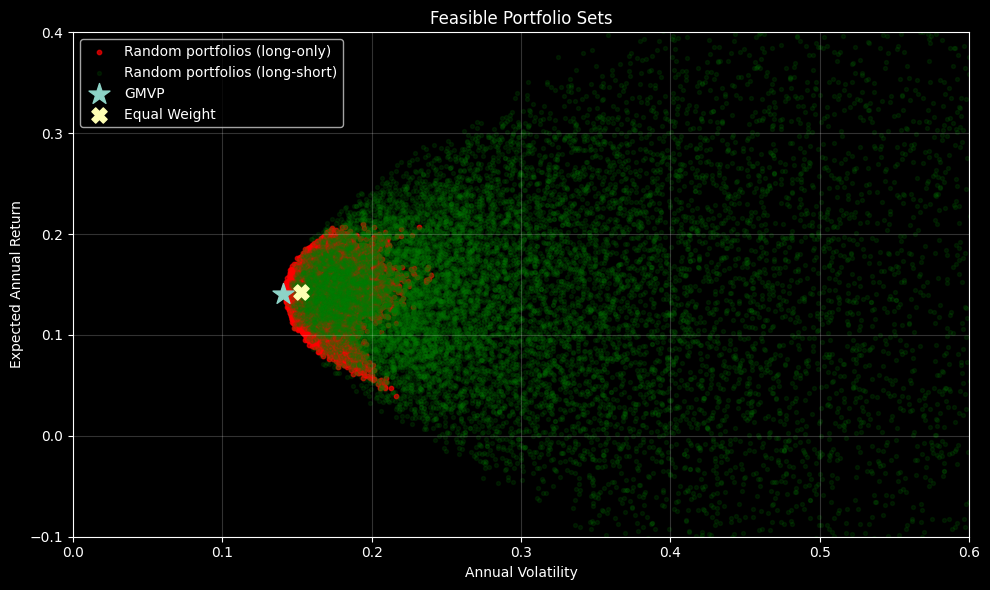

In [13]:
plt.figure(figsize=(10,6))

# Long-only portfolios
plt.scatter(
    long_only_volatility,
    long_only_returns,
    c='red',
    s=10,
    alpha=0.7,
    label="Random portfolios (long-only)"
)

# Long-short portfolios
plt.scatter(
    long_short_volatility,
    long_short_returns,
    c='green',
    s=8,
    alpha=0.15,
    label="Random portfolios (long-short)"
)

# GMVP
plt.scatter(
    gmvp_volatility,
    gmvp_return,
    marker="*",
    s=250,
    label="GMVP"
)

# Equal-weight
plt.scatter(
    equal_weight_volatility,
    equal_weight_return,
    marker="X",
    s=120,
    label="Equal Weight"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Feasible Portfolio Sets")

plt.xlim(0, 0.6)
plt.ylim(-0.1, 0.4)

plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Interpretation

The scatter plot shows the set of feasible portfolios generated through random sampling.

Two portfolio sets are visible:

• **Long-only portfolios** form a constrained region because weights must be positive.
• **Long-short portfolios** occupy a wider region since negative weights allow additional hedging opportunities.

The **Global Minimum Variance Portfolio** appears near the left boundary of the feasible set, confirming that it achieves the lowest volatility among fully-invested portfolios.

In the next section, we move beyond random sampling and construct the **Efficient Frontier**, which represents the set of portfolios that minimize volatility for each target return level.

## 10. Efficient Frontier

The **Efficient Frontier**, introduced by Harry Markowitz (1952), represents the set of portfolios that achieve the **minimum possible volatility for a given level of expected return**.

While the random portfolios generated in the previous section illustrate the feasible portfolio space, the efficient frontier is obtained by solving a constrained optimization problem.

### Optimization Problem

For a given target return $r_{\text{target}}$, we solve:

$$
\min_{w} \quad w^T \Sigma w
$$

subject to

$$
w^T \mu = r_{\text{target}}
$$

$$
\mathbf{1}^T w = 1
$$

where:

- $w$ is the vector of portfolio weights
- $\Sigma$ is the covariance matrix of asset returns
- $\mu$ is the vector of expected returns
- $\mathbf{1}$ is a vector of ones

### Interpretation

The optimization finds the portfolio that:

- achieves the specified **target return**
- has the **lowest possible variance**
- is **fully invested** (weights sum to one)

By solving this optimization for many target return values, we obtain a continuous curve known as the **Efficient Frontier**.

Portfolios lying on this frontier are considered **efficient**, meaning no other portfolio exists with higher return for the same risk or lower risk for the same return.

### Portfolio variance function

In [14]:
def portfolio_variance(weights, covariance_matrix):
    return weights.T @ covariance_matrix @ weights

### Efficient Frontier Optimization

In [15]:
target_returns = np.linspace(
    min(long_only_returns),
    max(long_only_returns),
    50
)

efficient_volatility = []

for target in target_returns:

    constraints = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "eq", "fun": lambda w: w @ annual_expected_returns - target}
    )

    initial_weights = np.ones(number_of_assets) / number_of_assets

    result = minimize(
        portfolio_variance,
        initial_weights,
        args=(annual_cov_df.values,),
        method="SLSQP",
        constraints=constraints
)

    efficient_volatility.append(np.sqrt(result.fun))

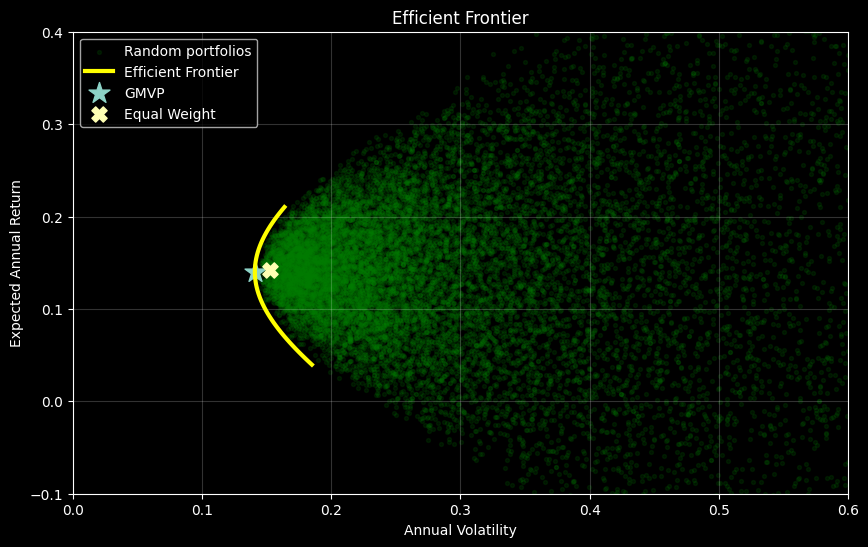

In [16]:
plt.figure(figsize=(10,6))

# Random portfolios
plt.scatter(long_short_volatility, long_short_returns,
            c="green", s=8, alpha=0.15, label="Random portfolios")

# Efficient frontier
plt.plot(efficient_volatility, target_returns,
         color="yellow", linewidth=3, label="Efficient Frontier")

# GMVP
plt.scatter(gmvp_volatility, gmvp_return,
            marker="*", s=250, label="GMVP")

# Equal weight
plt.scatter(equal_weight_volatility, equal_weight_return,
            marker="X", s=120, label="Equal Weight")

plt.xlabel("Annual Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Efficient Frontier")

plt.xlim(0,0.6)
plt.ylim(-0.1,0.4)

plt.legend()
plt.grid(alpha=0.2)

plt.show()

## 11. Maximum Sharpe Ratio Portfolio (Tangency Portfolio)

When a risk-free asset is available, investors seek the portfolio that maximizes the **Sharpe Ratio**, defined as the excess return per unit of risk.

The Sharpe Ratio is:

$$
S = \frac{E[R_p] - r_f}{\sigma_p}
$$

where:

- $E[R_p]$ is the expected portfolio return
- $r_f$ is the risk-free rate
- $\sigma_p$ is the portfolio volatility

The portfolio that maximizes this ratio is called the **Tangency Portfolio** because it lies at the point where the **Capital Market Line** is tangent to the efficient frontier.

To compute it, we solve the optimization problem:

$$
\max_w \frac{w^T \mu - r_f}{\sqrt{w^T \Sigma w}}
$$

subject to

$$
\mathbf{1}^T w = 1
$$

In [17]:
# Risk Free rate will be 2%
risk_free_rate = 0.02

In [18]:
# Negative Sharpe function
def negative_sharpe_ratio(weights, expected_returns, covariance_matrix, risk_free_rate):

    portfolio_return = weights @ expected_returns
    portfolio_volatility = np.sqrt(weights.T @ covariance_matrix @ weights)

    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

    return -sharpe_ratio

In [19]:
# Optimization
constraints = (
    {"type": "eq", "fun": lambda w: np.sum(w) - 1}
)

initial_weights = np.ones(number_of_assets) / number_of_assets

result = minimize(
    negative_sharpe_ratio,
    initial_weights,
    args=(annual_expected_returns, annual_cov_df.values, risk_free_rate),
    method="SLSQP",
    constraints=constraints
)

tangency_weights = result.x


In [20]:
# Return and volatility
tangency_return = tangency_weights @ annual_expected_returns
tangency_variance = tangency_weights.T @ annual_cov_df.values @ tangency_weights
tangency_volatility = np.sqrt(tangency_variance)

tangency_return, tangency_volatility

(np.float64(0.2561183762037612), np.float64(0.19743668306092163))

In [21]:
# Converting weights to labeled series
tangency_weights = pd.Series(tangency_weights, index=tickers)

tangency_weights.sort_values(ascending=False)

WMT     0.537881
JNJ     0.336702
XOM     0.319821
JPM     0.072431
AAPL    0.040225
MSFT    0.030151
KO      0.021886
PFE    -0.359096
dtype: float64

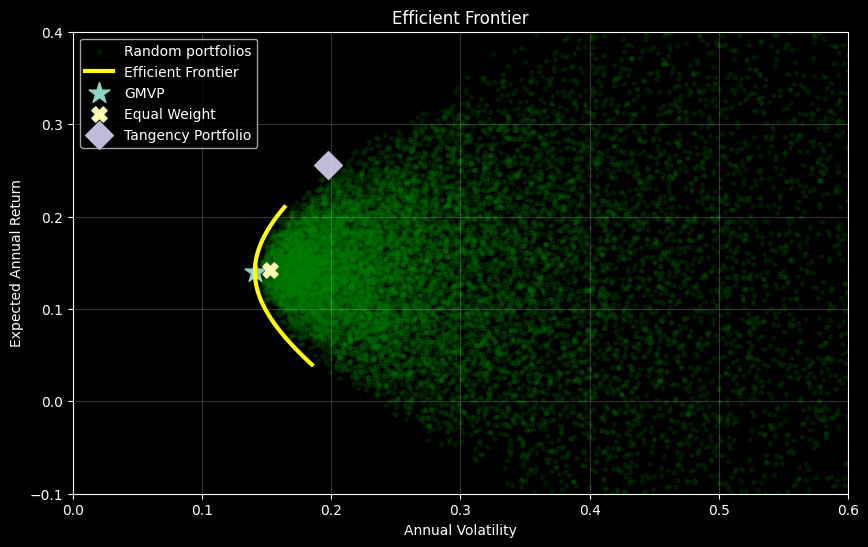

In [22]:
plt.figure(figsize=(10,6))

# Random portfolios
plt.scatter(long_short_volatility, long_short_returns,
            c="green", s=8, alpha=0.15, label="Random portfolios")

# Efficient frontier
plt.plot(efficient_volatility, target_returns,
         color="yellow", linewidth=3, label="Efficient Frontier")

# GMVP
plt.scatter(gmvp_volatility, gmvp_return,
            marker="*", s=250, label="GMVP")

# Equal weight
plt.scatter(equal_weight_volatility, equal_weight_return,
            marker="X", s=120, label="Equal Weight")

# Tangency Portfolio
plt.scatter(
    tangency_volatility,
    tangency_return,
    marker="D",
    s=200,
    label="Tangency Portfolio"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Efficient Frontier")

plt.xlim(0,0.6)
plt.ylim(-0.1,0.4)

plt.legend()
plt.grid(alpha=0.2)

plt.show()

### Interpretation

The tangency portfolio maximizes the Sharpe Ratio and therefore provides the best trade-off between return and risk when a risk-free asset is available.

Compared to the GMVP, the tangency portfolio typically has:

- higher expected return
- higher volatility
- a higher Sharpe ratio

This portfolio represents the **optimal risky portfolio** in modern portfolio theory.

## 12. Capital Market Line

When a risk-free asset is available, the set of optimal portfolios is no longer described only by the efficient frontier of risky assets.

Instead, investors can combine:

- the **risk-free asset**
- the **Tangency Portfolio**

This generates the **Capital Market Line (CML)**, which gives the highest expected return for each level of risk among all portfolios that combine the risk-free asset with the optimal risky portfolio.

The equation of the Capital Market Line is:

$$
E[R_c] = r_f + \frac{E[R_T] - r_f}{\sigma_T}\sigma_c
$$

where:

- $r_f$ is the risk-free rate
- $E[R_T]$ is the expected return of the tangency portfolio
- $\sigma_T$ is the volatility of the tangency portfolio
- $\sigma_c$ is the volatility of a portfolio on the Capital Market Line

The slope of the CML is equal to the **Sharpe Ratio of the tangency portfolio**.

In [23]:
cml_volatility = np.linspace(0, 0.6, 100)

cml_return = risk_free_rate + (
    (tangency_return - risk_free_rate) / tangency_volatility
) * cml_volatility

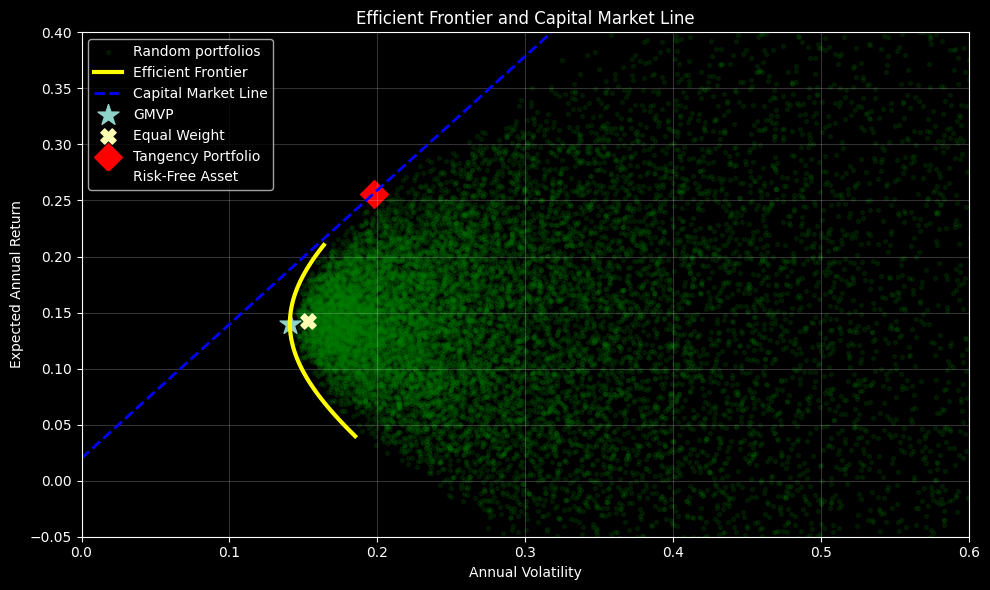

In [24]:

plt.figure(figsize=(10, 6))

# Random portfolios
plt.scatter(
    long_short_volatility,
    long_short_returns,
    c="green",
    s=8,
    alpha=0.15,
    label="Random portfolios"
)

# Efficient frontier
plt.plot(
    efficient_volatility,
    target_returns,
    color="yellow",
    linewidth=3,
    label="Efficient Frontier"
)

# Capital Market Line
plt.plot(
    cml_volatility,
    cml_return,
    color="blue",
    linewidth=2,
    linestyle="--",
    label="Capital Market Line"
)

# GMVP
plt.scatter(
    gmvp_volatility,
    gmvp_return,
    marker="*",
    s=250,
    label="GMVP"
)

# Equal-weight portfolio
plt.scatter(
    equal_weight_volatility,
    equal_weight_return,
    marker="X",
    s=120,
    label="Equal Weight"
)

# Tangency portfolio
plt.scatter(
    tangency_volatility,
    tangency_return,
    marker="D",
    color="red",
    s=200,
    label="Tangency Portfolio"
)

# Risk-free asset
plt.scatter(
    0,
    risk_free_rate,
    marker="o",
    color="black",
    s=100,
    label="Risk-Free Asset"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Efficient Frontier and Capital Market Line")

plt.xlim(0, 0.6)
plt.ylim(-0.05, 0.4)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Interpretation

The Capital Market Line represents the set of portfolios obtained by combining the risk-free asset with the tangency portfolio.

Its key implication is that, when a risk-free asset is available, rational investors should not simply choose any portfolio on the efficient frontier. Instead, they should select a combination of:

- the risk-free asset
- the tangency portfolio

More risk-averse investors will allocate more capital to the risk-free asset, while more risk-tolerant investors may leverage the tangency portfolio.

The tangency portfolio is therefore the **optimal risky portfolio**, and the Capital Market Line dominates the efficient frontier of risky assets alone.

## 13. Limitations and Assumptions

While mean–variance portfolio optimization provides a powerful mathematical framework for portfolio selection, the model relies on several assumptions and simplifications.

### Estimation risk

Expected returns and covariance matrices are estimated using historical data. These estimates may not accurately reflect future market behavior, and small estimation errors can significantly affect the resulting portfolio weights.

### Sensitivity to expected returns

Mean–variance optimization is particularly sensitive to errors in expected return estimates. Even minor changes in expected returns can lead to large changes in optimal portfolio allocations.

### Market frictions

The model assumes frictionless markets, meaning it ignores transaction costs, taxes, bid–ask spreads, and liquidity constraints. In real-world investing, these factors can influence portfolio performance and feasibility.

### Short-selling assumptions

Some portfolio constructions in this analysis allow short-selling. In practice, short-selling may be restricted or expensive, and many investors operate under long-only constraints.

### Constant risk-free rate

The analysis assumes a constant risk-free rate throughout the investment horizon. In reality, interest rates fluctuate over time.

### Distributional assumptions

Mean–variance optimization implicitly focuses on the first two moments of returns (mean and variance). However, financial returns may exhibit skewness, fat tails, and other characteristics not captured by variance alone.

## 14. Conclusion

This project implemented mean–variance portfolio optimization using historical data for eight large-cap US stocks, evaluated from the perspective of a EUR-based investor.

The analysis estimated expected returns and the covariance structure of asset returns, constructed the Global Minimum Variance Portfolio, and explored the feasible portfolio space through random portfolio simulations.

The Efficient Frontier was then computed using constrained optimization, identifying the set of portfolios that minimize risk for each target return. When a risk-free asset was introduced, the Maximum Sharpe Ratio (Tangency) Portfolio was determined, and the Capital Market Line was derived.

The results show that portfolio optimization can significantly improve the trade-off between return and risk compared to naive allocation strategies such as equal-weight portfolios. The tangency portfolio provides the optimal risky portfolio when investors can combine risky assets with a risk-free asset.

Overall, this project demonstrates how mathematical optimization and statistical estimation can be applied to portfolio construction, while also highlighting the importance of understanding the assumptions and limitations of the mean–variance framework.